In [1]:
# ==========================================
# 1. CONFIGURACIÓN
# ==========================================
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, Input, LSTM, Conv1D,
    MaxPooling1D, Flatten, BatchNormalization
)
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ------------------------------------------
# Rutas
# ------------------------------------------
DATA_PATH = "/content/drive/MyDrive/Curso Especializacion/Proyecto/master_dataset_colab.csv"
RESULTS_DIR = "/content/drive/MyDrive/Curso Especializacion/Proyecto/results"
DAY7_RESULTS = os.path.join(RESULTS_DIR, "day7_architecture_results.csv")
os.makedirs(RESULTS_DIR, exist_ok=True)

RESULTS_CSV = os.path.join(RESULTS_DIR, "day9_comparison_results.csv")

In [4]:
# Hiperparámetros (mejores del Día 6)
BEST_LR = 0.001
BEST_BATCH = 64
BEST_SEQ = 24
BEST_DROPOUT = 0.2

# Intentar cargar mejores hiperparámetros
day6_path = os.path.join(RESULTS_DIR, "day6_hyperparams_results.csv")
if os.path.exists(day6_path):
    day6_df = pd.read_csv(day6_path)
    best6 = day6_df.dropna(subset=['test_mae_real']).nsmallest(1, 'test_mae_real').iloc[0]
    BEST_LR = best6['learning_rate']
    BEST_BATCH = int(best6['batch_size'])
    BEST_SEQ = int(best6['seq_length'])
    BEST_DROPOUT = best6['dropout']
    print(f"  Mejores hiperparámetros cargados: lr={BEST_LR}, batch={BEST_BATCH}")

  Mejores hiperparámetros cargados: lr=0.001, batch=64


In [5]:
# ==========================================
# 2. CARGA Y PREPARACIÓN DE DATOS
# ==========================================
print("\n📂 Cargando datos...")
df = pd.read_csv(DATA_PATH)
print(f"  Shape: {df.shape}")


def create_sequences_by_station(data, seq_length, target_col_name='pm25', group_col='station_name'):
    """Genera secuencias temporales agrupadas por estación."""
    xs, ys = [], []
    for station, group in data.groupby(group_col):
        group_no_station = group.drop(columns=[group_col])
        group_values = group_no_station.values
        target_values = group[target_col_name].values
        for i in range(len(group_values) - seq_length):
            xs.append(group_values[i:(i + seq_length), :])
            ys.append(target_values[i + seq_length])
    return np.array(xs), np.array(ys)


df['fecha'] = pd.to_datetime(df['fecha'])
# Eliminar la columna 'fecha' antes de pasar al modelo, ya que ya tenemos características de tiempo numéricas
df = df.drop(columns=['fecha'])
print(f"Columnas después de eliminar 'fecha': {list(df.columns)}")
print(f"Tipos de datos actualizados:\n{df.dtypes}")




# Normalización
scaler = MinMaxScaler()
cols_to_scale = [c for c in df.columns if c != 'station_name']
df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
pm25_col_idx = cols_to_scale.index('pm25')
n_features = len(cols_to_scale)

# Crear secuencias
X, y = create_sequences_by_station(df_scaled, BEST_SEQ)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"  Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")


def inverse_pm25(values):
    """Desnormaliza PM2.5."""
    dummy = np.zeros((len(values), n_features))
    dummy[:, pm25_col_idx] = values.flatten()
    dummy_inv = scaler.inverse_transform(dummy)
    return dummy_inv[:, pm25_col_idx]


def evaluate(model, model_name):
    """Evalúa un modelo y devuelve métricas en escala real."""
    y_pred = model.predict(X_test)
    y_test_real = inverse_pm25(y_test)
    y_pred_real = inverse_pm25(y_pred)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    r2 = r2_score(y_test_real, y_pred_real)
    print(f"  📊 {model_name}: MAE={mae:.4f} | RMSE={rmse:.4f} | R²={r2:.4f}")
    return {'model': model_name, 'mae': round(mae, 4), 'rmse': round(rmse, 4), 'r2': round(r2, 4)}


📂 Cargando datos...
  Shape: (195183, 22)
Columnas después de eliminar 'fecha': ['pm25', 'no2', 'o3', 'temperatura', 'velocidad_viento', 'precipitacion', 'humedad_relativa', 'hora_del_dia', 'dia_de_la_semana', 'pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_rolling_6h', 'station_name', 'station_Francia', 'station_Molí del Sol', 'station_Pista de Silla', 'station_Puerto Moll Trans. Ponent', 'station_Puerto Valencia', 'station_Puerto llit antic Túria', 'station_Universidad Politécnica']
Tipos de datos actualizados:
pm25                                 float64
no2                                  float64
o3                                   float64
temperatura                          float64
velocidad_viento                     float64
precipitacion                        float64
humedad_relativa                     float64
hora_del_dia                           int64
dia_de_la_semana                       int64
pm25_lag1                            float64
pm25_lag2                        

In [6]:
# ==========================================
# 3. MODELO FC (FULLY CONNECTED) — Baseline
# ==========================================
print(f"\n{'='*60}")
print("🔄 Entrenando modelo FC (Fully Connected)")
print(f"{'='*60}")

# Para FC, aplanamos las secuencias
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

fc_model = Sequential([
    Input(shape=(X_train_flat.shape[1],)),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(BEST_DROPOUT),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(BEST_DROPOUT),
    Dense(64, activation='relu'),
    Dropout(BEST_DROPOUT),
    Dense(32, activation='relu'),
    Dense(1)
])
fc_model.compile(optimizer=Adam(learning_rate=BEST_LR), loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

start = time.time()
hist_fc = fc_model.fit(
    X_train_flat, y_train, epochs=80, batch_size=BEST_BATCH,
    validation_data=(X_val_flat, y_val),
    callbacks=[early_stop, reduce_lr], verbose=1
)
time_fc = time.time() - start

# Para evaluar FC necesitamos un wrapper
class FCWrapper:
    def __init__(self, model, input_shape):
        self.model = model
        self.input_shape = input_shape
    def predict(self, X):
        X_flat = X.reshape(X.shape[0], -1)
        return self.model.predict(X_flat)

fc_wrapper = FCWrapper(fc_model, X_train_flat.shape[1])
result_fc = evaluate(fc_wrapper, "FC (Dense)")
result_fc['n_params'] = fc_model.count_params()
result_fc['training_time'] = round(time_fc, 1)
result_fc['type'] = 'Fully Connected'


🔄 Entrenando modelo FC (Fully Connected)
Epoch 1/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 0.0211 - mae: 0.0901 - val_loss: 0.0063 - val_mae: 0.0510 - learning_rate: 0.0010
Epoch 2/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0059 - mae: 0.0508 - val_loss: 0.0043 - val_mae: 0.0403 - learning_rate: 0.0010
Epoch 3/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0052 - mae: 0.0460 - val_loss: 0.0043 - val_mae: 0.0399 - learning_rate: 0.0010
Epoch 4/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0049 - mae: 0.0440 - val_loss: 0.0042 - val_mae: 0.0415 - learning_rate: 0.0010
Epoch 5/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0048 - mae: 0.0431 - val_loss: 0.0043 - val_mae: 0.0400 - learning_rate: 0.0010
Epoch 6/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0047 - mae: 0.0423 - val_loss: 0.0042 - val_mae: 0.0404 - learning_rate: 0.0010
Epoch 7/80
2125/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0047 - mae: 0.0420
Epoch 7: R

In [7]:
# ==========================================
# 4. MODELO CNN 1D
# ==========================================
print(f"\n{'='*60}")
print("🔄 Entrenando modelo CNN 1D")
print(f"{'='*60}")

cnn_model = Sequential([
    Input(shape=(BEST_SEQ, X.shape[2])),
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(BEST_DROPOUT),
    Dense(32, activation='relu'),
    Dense(1)
])
cnn_model.compile(optimizer=Adam(learning_rate=BEST_LR), loss='mse', metrics=['mae'])
cnn_model.summary()

start = time.time()
hist_cnn = cnn_model.fit(
    X_train, y_train, epochs=80, batch_size=BEST_BATCH,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr], verbose=1
)
time_cnn = time.time() - start

result_cnn = evaluate(cnn_model, "CNN 1D")
result_cnn['n_params'] = cnn_model.count_params()
result_cnn['training_time'] = round(time_cnn, 1)
result_cnn['type'] = 'Convolutional'


🔄 Entrenando modelo CNN 1D


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 24, 64)         │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 12, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 6, 64)          │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,769 (315.50 KB)

 Trainable params: 80,385 (314.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 0.0082 - mae: 0.0547 - val_loss: 0.0045 - val_mae: 0.0396 - learning_rate: 0.0010
Epoch 2/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0045 - mae: 0.0406 - val_loss: 0.0043 - val_mae: 0.0384 - learning_rate: 0.0010
Epoch 3/80
2120/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0045 - mae: 0.0402
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0044 - mae: 0.0399 - val_loss: 0.0045 - val_mae: 0.0395 - learning_rate: 0.0010
Epoch 4/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0041 - mae: 0.0377 - val_loss: 0.0042 - val_mae: 0.0380 - learning_rate: 5.0000e-04
Epoch 5/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0041 - mae: 0.0375 - val_loss: 0.0044 - val_mae: 0.0395 - learning_rate: 5.0000e-04
Epoch 6/80
2127/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0042 - mae: 0.0373
Epoch 6: ReduceLROnPlateau reducing lea

In [8]:
# ==========================================
# 5. CARGAR RESULTADOS PREVIOS
# ==========================================
print(f"\n{'='*60}")
print("📋 Cargando resultados de Días anteriores")
print(f"{'='*60}")

all_results = [result_fc, result_cnn]

# Cargar resultados del Día 7 (LSTM variants)
if os.path.exists(DAY7_RESULTS):
    day7_df = pd.read_csv(DAY7_RESULTS)
    for _, row in day7_df.iterrows():
        all_results.append({
            'model': row['architecture'],
            'mae': row['test_mae_real'],
            'rmse': row['test_rmse_real'],
            'r2': row['test_r2_real'],
            'n_params': int(row['n_params']),
            'training_time': row['training_time_sec'],
            'type': 'LSTM' if 'LSTM' in row['architecture'] else 'Other',
        })
    print(f"  ✅ Cargados {len(day7_df)} modelos del Día 7")
else:
    print("  ⚠️ No se encontraron resultados del Día 7")

# Agregar ensemble si existe
day8_path = os.path.join(RESULTS_DIR, "day8_advanced_results.csv")
if os.path.exists(day8_path):
    try:
        day8_df = pd.read_csv(day8_path)
        # Parsear el dict string del ensemble
        ensemble_str = day8_df.iloc[0]['ensemble']
        # Intentar extraer MAE del ensemble
        import ast
        ensemble_dict = ast.literal_eval(ensemble_str.replace('np.float64(', '').replace(')', ''))
        all_results.append({
            'model': 'Ensemble (3 LSTM)',
            'mae': round(ensemble_dict['mae'], 4),
            'rmse': round(ensemble_dict['rmse'], 4),
            'r2': round(ensemble_dict['r2'], 4),
            'n_params': 0,
            'training_time': 0,
            'type': 'Ensemble',
        })
        print("  ✅ Cargado resultado del Ensemble (Día 8)")
    except Exception as e:
        print(f"  ⚠️ Error cargando ensemble: {e}")


📋 Cargando resultados de Días anteriores
  ✅ Cargados 4 modelos del Día 7
  ✅ Cargado resultado del Ensemble (Día 8)


In [9]:
# ==========================================
# 6. TABLA COMPARATIVA
# ==========================================
print(f"\n{'='*60}")
print("📊 COMPARATIVA COMPLETA DE MODELOS")
print(f"{'='*60}")

comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df.sort_values('mae')
comparison_df.to_csv(RESULTS_CSV, index=False)

print(f"\n🏆 Ranking por MAE:")
print(comparison_df[['model', 'type', 'mae', 'rmse', 'r2', 'n_params', 'training_time']].to_string(index=False))


📊 COMPARATIVA COMPLETA DE MODELOS

🏆 Ranking por MAE:
            model            type    mae   rmse     r2  n_params  training_time
   LSTM_Attention            LSTM 2.6375 4.6949 0.7672    126818          425.3
      LSTM_3Layer            LSTM 2.6517 4.8021 0.7565    138657          417.1
Ensemble (3 LSTM)        Ensemble 2.6786 4.7484 0.7619         0            0.0
           BiLSTM            LSTM 2.7549 4.7455 0.7622     85793          305.3
       FC (Dense) Fully Connected 2.7780 4.8800 0.7485    167937          214.8
      LSTM_2Layer            LSTM 2.7932 4.8977 0.7467    126753          159.3
           CNN 1D   Convolutional 2.9761 5.0987 0.7255     80769           76.3



📈 Generando visualizaciones...


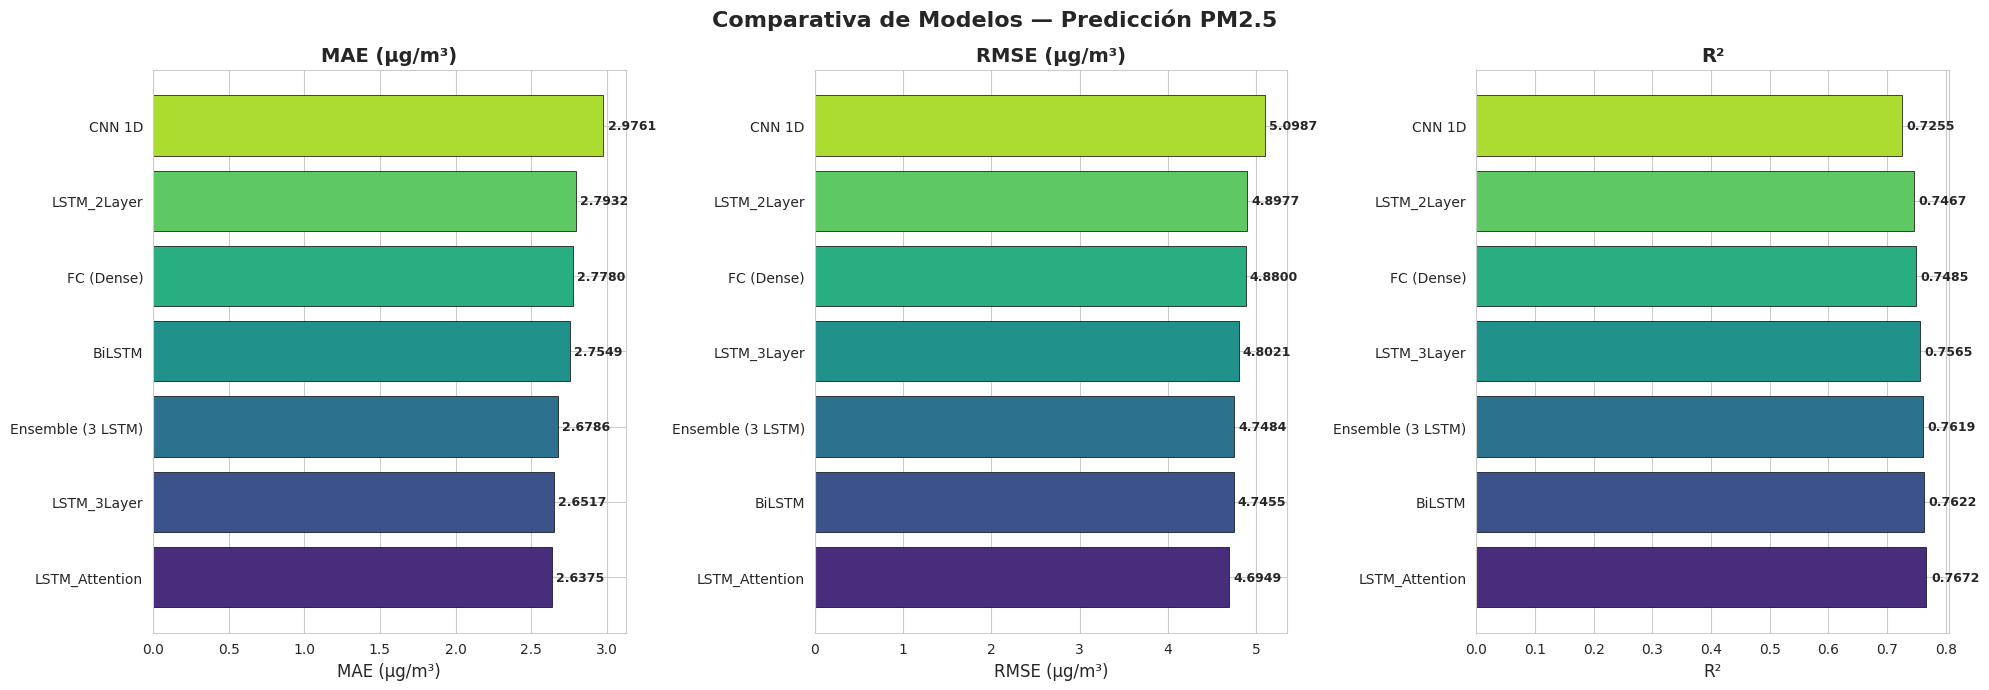

✅ Comparativa guardada en: /content/drive/MyDrive/Curso Especializacion/Proyecto/results/day9_model_comparison.png


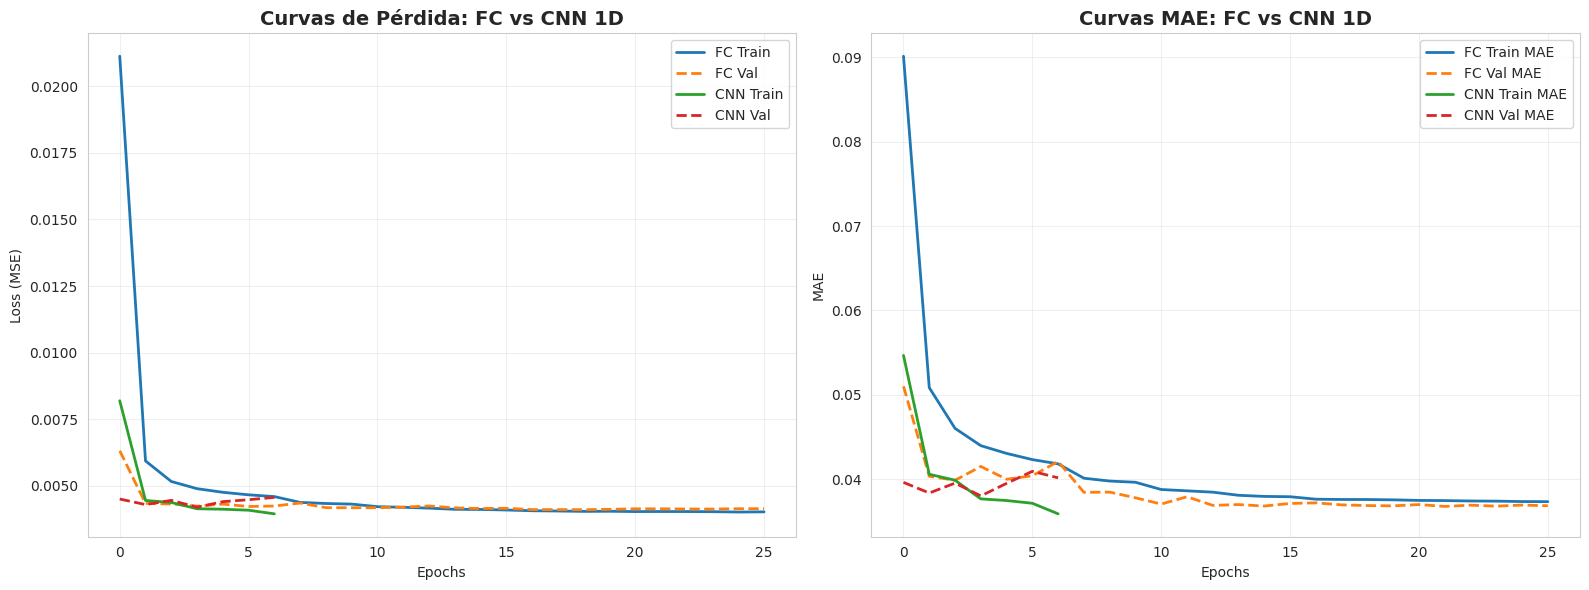

✅ Curvas guardadas en: /content/drive/MyDrive/Curso Especializacion/Proyecto/results/day9_fc_cnn_curves.png


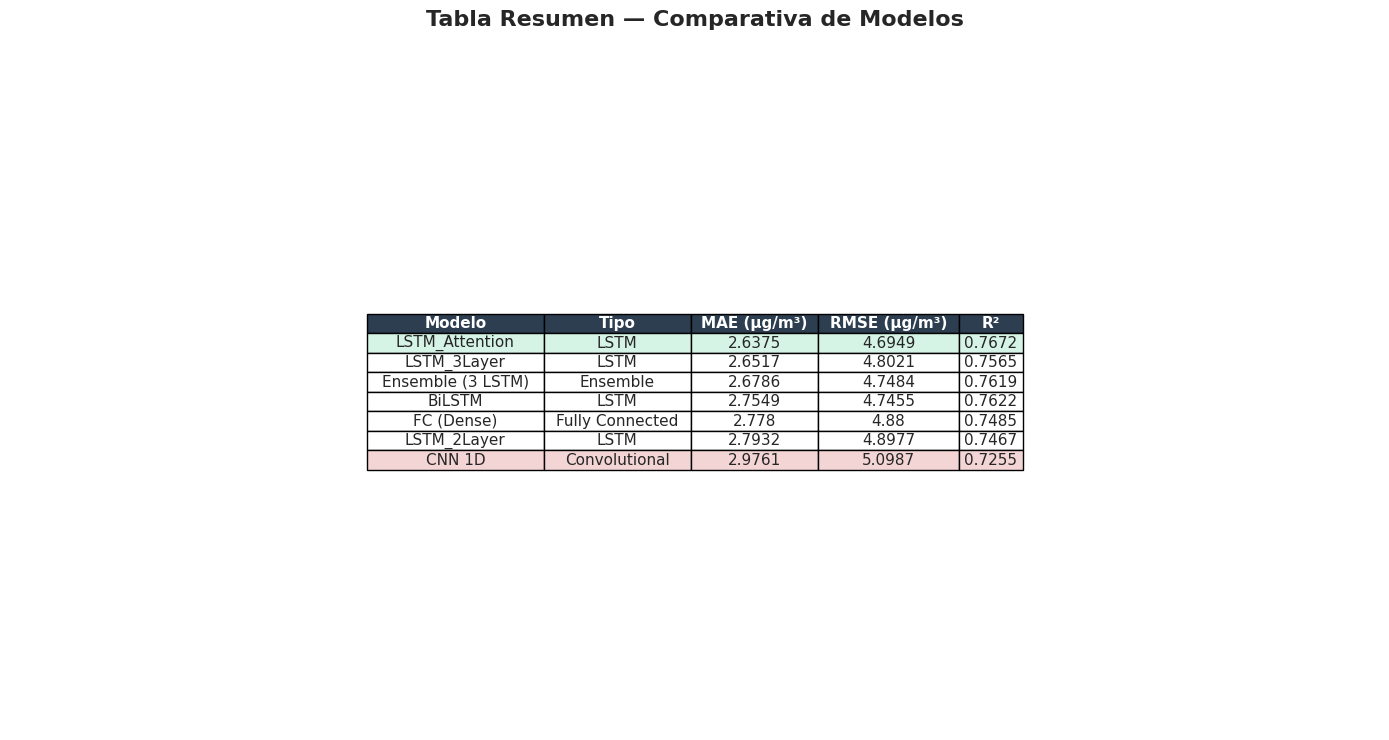

✅ Tabla resumen guardada en: /content/drive/MyDrive/Curso Especializacion/Proyecto/results/day9_summary_table.png


In [10]:
# ==========================================
# 7. VISUALIZACIONES
# ==========================================
print(f"\n📈 Generando visualizaciones...")

# --- 7.1 Barras comparativas ---
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
palette = sns.color_palette('viridis', len(comparison_df))

for idx, (metric, title, lower_better) in enumerate([
    ('mae', 'MAE (µg/m³)', True),
    ('rmse', 'RMSE (µg/m³)', True),
    ('r2', 'R²', False),
]):
    ax = axes[idx]
    sorted_df = comparison_df.sort_values(metric, ascending=lower_better)
    colors = [palette[i] for i in range(len(sorted_df))]

    bars = ax.barh(sorted_df['model'], sorted_df[metric], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xlabel(title, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')

    for bar, val in zip(bars, sorted_df[metric]):
        offset = val * 0.01 if lower_better else val * 0.01
        ax.text(val + offset, bar.get_y() + bar.get_height()/2.,
                f'{val:.4f}', ha='left', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Comparativa de Modelos — Predicción PM2.5', fontsize=16, fontweight='bold')
plt.tight_layout()
comparison_path = os.path.join(RESULTS_DIR, "day9_model_comparison.png")
plt.savefig(comparison_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Comparativa guardada en: {comparison_path}")


# --- 7.2 Curvas de entrenamiento FC vs CNN ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(hist_fc.history['loss'], label='FC Train', linewidth=2, linestyle='-')
ax.plot(hist_fc.history['val_loss'], label='FC Val', linewidth=2, linestyle='--')
ax.plot(hist_cnn.history['loss'], label='CNN Train', linewidth=2, linestyle='-')
ax.plot(hist_cnn.history['val_loss'], label='CNN Val', linewidth=2, linestyle='--')
ax.set_title('Curvas de Pérdida: FC vs CNN 1D', fontsize=14, fontweight='bold')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss (MSE)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(hist_fc.history['mae'], label='FC Train MAE', linewidth=2, linestyle='-')
ax.plot(hist_fc.history['val_mae'], label='FC Val MAE', linewidth=2, linestyle='--')
ax.plot(hist_cnn.history['mae'], label='CNN Train MAE', linewidth=2, linestyle='-')
ax.plot(hist_cnn.history['val_mae'], label='CNN Val MAE', linewidth=2, linestyle='--')
ax.set_title('Curvas MAE: FC vs CNN 1D', fontsize=14, fontweight='bold')
ax.set_xlabel('Epochs')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
curves_path = os.path.join(RESULTS_DIR, "day9_fc_cnn_curves.png")
plt.savefig(curves_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Curvas guardadas en: {curves_path}")


# --- 7.3 Tabla resumen estilizada ---
fig, ax = plt.subplots(figsize=(14, 4 + len(comparison_df) * 0.5))
ax.axis('off')

table_data = comparison_df[['model', 'type', 'mae', 'rmse', 'r2']].values.tolist()
col_labels = ['Modelo', 'Tipo', 'MAE (µg/m³)', 'RMSE (µg/m³)', 'R²']

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.auto_set_column_width(col=list(range(len(col_labels))))

# Colorear header
for j in range(len(col_labels)):
    table[(0, j)].set_facecolor('#2c3e50')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

# Colorear filas (verde para el mejor, rojo para el peor)
for i in range(1, len(table_data) + 1):
    if i == 1:  # Mejor modelo
        for j in range(len(col_labels)):
            table[(i, j)].set_facecolor('#d5f4e6')
    elif i == len(table_data):  # Peor modelo
        for j in range(len(col_labels)):
            table[(i, j)].set_facecolor('#f4d5d5')

ax.set_title('Tabla Resumen — Comparativa de Modelos', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
table_path = os.path.join(RESULTS_DIR, "day9_summary_table.png")
plt.savefig(table_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Tabla resumen guardada en: {table_path}")

In [11]:
# ==========================================
# 8. CONCLUSIONES
# ==========================================
best = comparison_df.iloc[0]
worst = comparison_df.iloc[-1]

print(f"\n{'='*60}")
print("📋 CONCLUSIONES")
print(f"{'='*60}")
print(f"\n  🏆 Mejor modelo: {best['model']}")
print(f"     MAE: {best['mae']:.4f} µg/m³ | RMSE: {best['rmse']:.4f} | R²: {best['r2']:.4f}")
print(f"\n  📉 Peor modelo: {worst['model']}")
print(f"     MAE: {worst['mae']:.4f} µg/m³ | RMSE: {worst['rmse']:.4f} | R²: {worst['r2']:.4f}")
print(f"\n  📊 Modelos evaluados: {len(comparison_df)}")

improvement = ((worst['mae'] - best['mae']) / worst['mae']) * 100
print(f"  📈 Mejora del mejor vs peor: {improvement:.1f}%")

print(f"\n✅ Resultados guardados en: {RESULTS_CSV}")
print("🎯 Comparativa completada. El mejor modelo se usará en la API Flask.")


📋 CONCLUSIONES

  🏆 Mejor modelo: LSTM_Attention
     MAE: 2.6375 µg/m³ | RMSE: 4.6949 | R²: 0.7672

  📉 Peor modelo: CNN 1D
     MAE: 2.9761 µg/m³ | RMSE: 5.0987 | R²: 0.7255

  📊 Modelos evaluados: 7
  📈 Mejora del mejor vs peor: 11.4%

✅ Resultados guardados en: /content/drive/MyDrive/Curso Especializacion/Proyecto/results/day9_comparison_results.csv
🎯 Comparativa completada. El mejor modelo se usará en la API Flask.
